# Use tensorflow Chapter 6

## Prepare data for training

In [2]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load the breast cancer dataset
# cancer ve dictionary
cancer = load_breast_cancer()
print(cancer.keys())
# print(cancer.data)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## Convert list data to dataframe

In [3]:
# create dataframe
df = pd.DataFrame(cancer.data[:,0:2], columns=cancer.feature_names[0:2])
# add label column
df['class'] = cancer.target
print(df.sample(5, random_state=1))

     mean radius  mean texture  class
421        14.69         13.98      1
47         13.17         18.66      0
292        12.95         16.02      1
186        18.31         18.58      0
414        15.13         29.81      0


Convert label class from 0,1 to description

In [4]:
#  df['class'] = np.where(df['class'] == 0, 'malignant', 'benign')
#  df['class'] = np.where(df['class'] == 0, 'yes', 'no')

target = {0: 'malignant', 1: 'benign'}
df['class'] = df['class'].map(target)
print(df.sample(5, random_state=1))

     mean radius  mean texture      class
421        14.69         13.98     benign
47         13.17         18.66  malignant
292        12.95         16.02     benign
186        18.31         18.58  malignant
414        15.13         29.81  malignant


Check Null

In [5]:
df.isnull().sum()

mean radius     0
mean texture    0
class           0
dtype: int64

Visualization

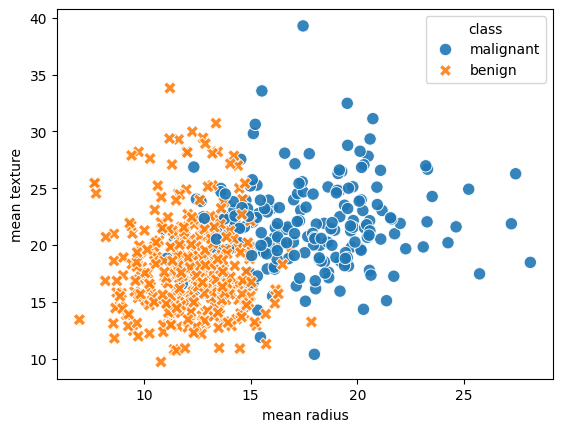

In [6]:
sns.scatterplot(x='mean radius', y='mean texture', hue='class', data=df, style='class',
                alpha=0.9, edgecolor='w' , s=80)
plt.show()

Label encoding

In [7]:
# encode label class
class_names, y = np.unique(df['class'], return_inverse=True)
# class_names type  : numpy.ndarray
# y type            : numpy.ndarray
print(class_names)
print(y[40:50])

['benign' 'malignant']
[1 1 1 1 1 1 0 1 0 0]


Prepare X

In [8]:
X = df.drop('class', axis=1)
X.sample(5, random_state=1)

,mean radius,mean texture
421,14.69,13.98
47,13.17,18.66
292,12.95,16.02
186,18.31,18.58
414,15.13,29.81


Standard Scale

In [9]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_sc = sc.fit_transform(X)
print(X_sc)

[[ 1.09706398 -2.07333501]
 [ 1.82982061 -0.35363241]
 [ 1.57988811  0.45618695]
 ...
 [ 0.70228425  2.0455738 ]
 [ 1.83834103  2.33645719]
 [-1.80840125  1.22179204]]


Visualization after standard scale

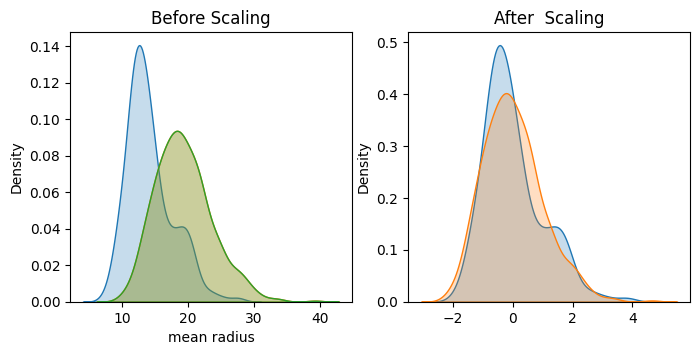

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 3.5))

ax1.set_title('Before Scaling')
sns.kdeplot(X['mean radius'], fill=True,ax=ax1)
sns.kdeplot(X['mean texture'], fill=True,ax=ax1)

ax2.set_title('After  Scaling')
sns.kdeplot(X_sc[:,0], fill=True, ax=ax2)
sns.kdeplot(X_sc[:,1], fill=True, ax=ax2)

sns.kdeplot(df['mean texture'], fill=True, ax=ax1)
plt.show()

plot data point

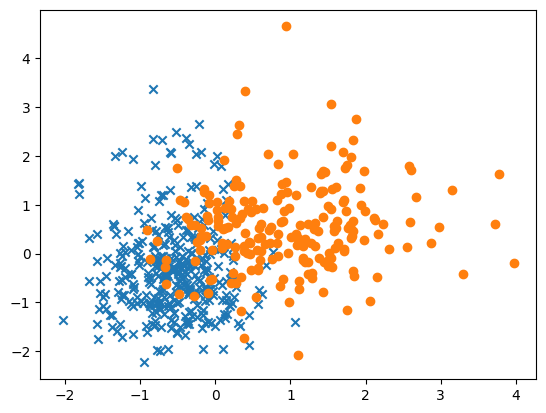

In [11]:
plt.scatter(X_sc[:,0][y==0], X_sc[:,1][y==0], label='malignant', marker='x')
plt.scatter(X_sc[:,0][y==1], X_sc[:,1][y==1], label='benign', marker='o')
plt.show()

Prepare Train data and test data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.25, random_state=1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((426, 2), (143, 2), (426,), (143,))

Create Model [Chapter 6 Workshop 2 ]

Create by Sequential model

In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

#  Create model
model = Sequential()

#  Add layer with 32 nodes with ReLU activation function
#  Input shape is 2 because we have 2 features
model.add(Dense(32, activation='relu', input_shape=(2,)))

#  Add layer with 1 node with sigmoid activation function
# For classification of 2 classes 0 or 1 so just 1 node
model.add(Dense(1, activation='sigmoid'))

d:\Programming_File\Environment\tf\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Create by Fuctional model

In [14]:
# from tensorflow.keras.layers import Dense, Input
# from tensorflow.keras import Model

# inputs = Input(shape=(2,))
# x = Dense(32, activation='relu')(inputs)
# outputs = Dense(1, activation='sigmoid')(x)

# model = Model(inputs = inputs, outputs = outputs, name='cancer_model')

Check model constructor

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129 (516.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

See the detail of the layers

In [16]:
model.get_config()

{'name': 'sequential',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 2),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer'},
   'registered_name': None},
  {'module': 'keras.layers',
   'class_name': 'Dense',
   'config': {'name': 'dense',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'units': 32,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 'keras.initializers',
     'class_name': 'Zeros',
     'config': {},
     'registered_name': None},
  

See Output shape

In [17]:
model.output_shape

(None, 1)

Compile model

In [18]:
model.compile(loss='binary_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

Train model

In [19]:
"""
Decription
X,y : Feature and label
epoch : Number of model train with sample datasets [10 epoch : model train with sample datasets 10 times]
batch_size : Number of samples per gradient update
validation_split : Fraction of training data to be used as validation data
verbose : 0 = silent, 1 = progress bar, 2 = one line per epoch

iteration : Number that weight is updated [ epoch * (n_samples / batch_size) ]
"""

import time
start = time.time()
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.25, verbose=1)
end = time.time()
print(f"Time taken to train model: {end - start:.3f} seconds")

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3819 - loss: 0.6992 - val_accuracy: 0.5607 - val_loss: 0.6753
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6208 - loss: 0.6574 - val_accuracy: 0.7757 - val_loss: 0.6362
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8254 - loss: 0.6142 - val_accuracy: 0.8318 - val_loss: 0.6018
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8677 - loss: 0.5801 - val_accuracy: 0.8505 - val_loss: 0.5719
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8669 - loss: 0.5469 - val_accuracy: 0.8598 - val_loss: 0.5448
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8963 - loss: 0.5144 - val_accuracy: 0.8505 - val_loss: 0.5201
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8924 - loss: 0.5019 - val_accuracy: 0.8598 - val_loss: 0.4977
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9015 - loss: 0.4733 - val_accuracy: 0.8692 - v

Evaluation model

In [20]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {score[0]}')
print(f'Test accuracy: {score[1]}')

Test loss: 0.3830701410770416
Test accuracy: 0.8321678042411804


Test prediction

In [21]:
y_pred_pr = model.predict(X_test)
y_pred_pr[:5]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0.24993627],
       [0.24344431],
       [0.17189567],
       [0.7639757 ],
       [0.82256967]], dtype=float32)

Decide result from threshold

In [22]:
y_pred = (y_pred_pr > 0.5).astype(int)
# y_pred = np.where(y_pred_pr > 0.5, 1, 0)
y_pred[:5]

array([[0],
       [0],
       [0],
       [1],
       [1]])

Plot loss curve

In [23]:
# history.history type : dictionary
df_history = pd.DataFrame.from_dict(history.history)
print(history.params)
print(history.history.keys())
print(df_history.head())

{'verbose': 1, 'epochs': 20, 'steps': 10}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
   accuracy      loss  val_accuracy  val_loss
0  0.388715  0.696266      0.560748  0.675260
1  0.673981  0.652243      0.775701  0.636245
2  0.811912  0.612553      0.831776  0.601812
3  0.855799  0.576383      0.850467  0.571871
4  0.871473  0.544924      0.859813  0.544848


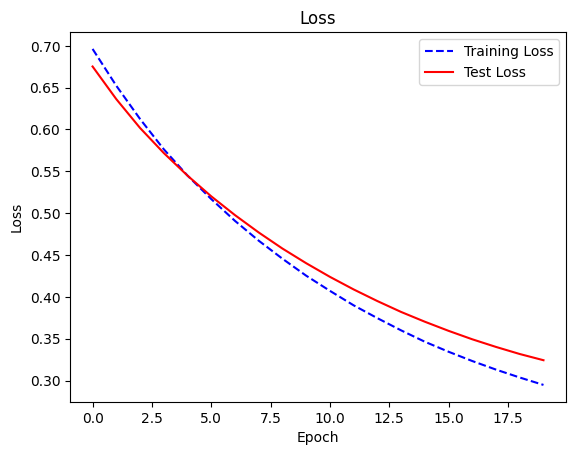

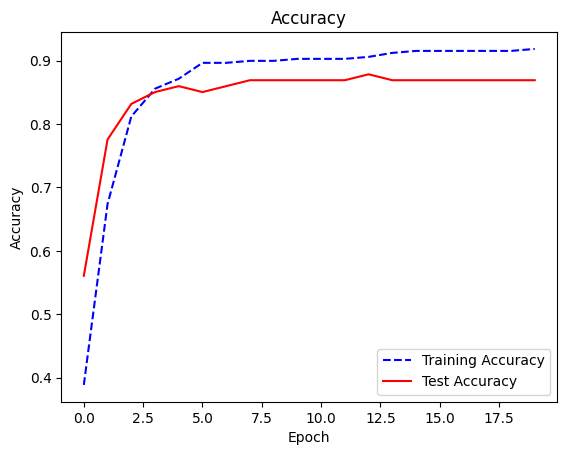

In [24]:
df_history['loss'].plot(style='b--', label='Training Loss')
df_history['val_loss'].plot(style='r-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.show()

df_history['accuracy'].plot(style='b--', label='Training Accuracy')
df_history['val_accuracy'].plot(style='r-', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

Using Tensor Board

In [25]:
from keras.callbacks import TensorBoard

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.25, verbose=1,
                    callbacks=[TensorBoard(log_dir='./logs')])

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9151 - loss: 0.2859 - val_accuracy: 0.8692 - val_loss: 0.3173
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9425 - loss: 0.2659 - val_accuracy: 0.8692 - val_loss: 0.3110
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9134 - loss: 0.2703 - val_accuracy: 0.8785 - val_loss: 0.3049
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9069 - loss: 0.2758 - val_accuracy: 0.8785 - val_loss: 0.2996
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9248 - loss: 0.2615 - val_accuracy: 0.8785 - val_loss: 0.2947
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9279 - loss: 0.2589 - val_accuracy: 0.8785 - val_loss: 0.2902
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9196 - loss: 0.2582 - val_accuracy: 0.8972 - val_loss: 0.2860
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8947 - loss: 0.2823 - val_accuracy: 0.9159 - v

In [26]:
# Lanuch Tensorboard
# %load_ext tensorboard
# %tensorboard --logdir ./logs

Model Boundary

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


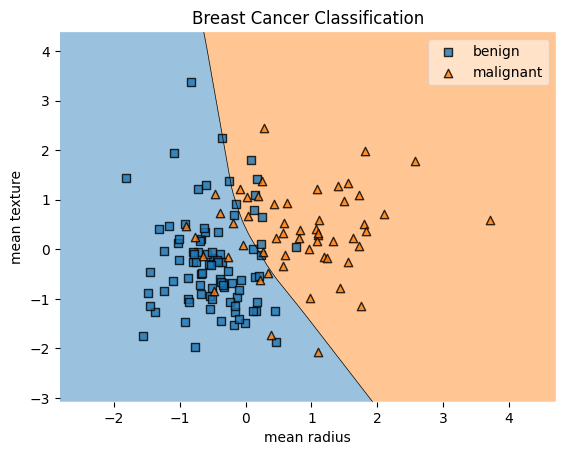

In [27]:
from mlxtend.plotting import plot_decision_regions

# Create Decision Boundary
ax = plot_decision_regions(X_test, y_test, clf=model)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, class_names, framealpha=0.5)

plt.xlabel('mean radius')
plt.ylabel('mean texture')
plt.title('Breast Cancer Classification')
plt.show()


Prediction

In [28]:
X_new = [[15.5, 21.3]
         ,[10.8, 19.3]
        ,[20.5, 20.9]]
# X_new = X[100:140] # Use data in dataset

# Standard scaling
X_new_sc = sc.transform(X_new)
print(X_new_sc)

[[ 0.38986863  0.46782229]
 [-0.94499809  0.00240886]
 [ 1.80993961  0.3747396 ]]


d:\Programming_File\Environment\tf\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [33]:
y_pred_pr = model.predict(X_new_sc)
y_pred = (y_pred_pr > 0.5).astype(int)
print(class_names[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[['malignant']
 ['benign']
 ['malignant']]


Prediction plotting

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


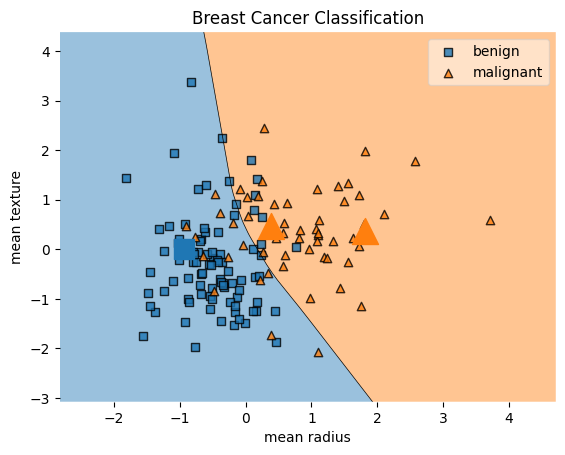

In [35]:
y_pred = y_pred.reshape(1,-1)[0] # be it be along in one row

# Plot datapoint
ax = plot_decision_regions(X_test, y_test, clf=model)
handles, lebels = ax.get_legend_handles_labels()
ax.legend(handles, class_names, framealpha=0.5)
plt.title('Breast Cancer Classification')
plt.xlabel('mean radius')
plt.ylabel('mean texture')
plt.yticks()

# Plot prediction
plt.scatter(X_new_sc[:,0][y_pred==0], X_new_sc[:,1][y_pred==0], s=200, marker='s')
plt.scatter(X_new_sc[:,0][y_pred==1], X_new_sc[:,1][y_pred==1], s=350, marker='^')
plt.show()

Sav Model [ Chapter 6 Workshop 3 ]

In [ ]:
model.save('./model/breast_cancer_model.h5')
# model.SavedModel('./model/mymodel')

AttributeError: 'Sequential' object has no attribute 'SavedModel'

Save Scaler and Class names [ Chapter 6 Workshop 4 ]

In [38]:
import pickle

pickle.dump(sc, open('./myproject/scaler.pkl', 'wb'))

In [40]:
file_name = './myproject/classname.pkl'

open_file = open(file_name, 'wb')
pickle.dump(class_names, open_file)
open_file.close()